# 08a — Headline Results & Comparison Tables (K-Fold Aggregated)
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**This notebook produces the headline numbers and ranking tables for the report's Results section.** It aggregates the per-fit metrics from notebook 06 across 5 folds, computing **mean ± std macro-F1** per (model × version × attribute).

### Tables produced

| Table | Purpose |
|---|---|
| **Headline** | Best tuned model per attribute, mean ± std across folds × seeds |
| **All-results matrix** | One row per model × version, columns = attributes |
| **Cross-attribute ranking** | Which model has the strongest average macro-F1 across attributes? |
| **Top-3 ranking per attribute** | First/Second/Third model per attribute |
| **Recall + Precision** | Per-class precision/recall for best models |
| **Fold-by-fold breakdown** | Macro-F1 per fold for the winning model (transparency) |

### Companion notebooks

- `08b_visual_analysis_and_stats.ipynb` — confusion matrices, ROC curves, statistical tests
- `08c_deep_analysis.ipynb` — feature importance, error analysis, RQ summary + scaling discussion


## 0. Setup

In [6]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

def find_project_root():
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATASET_VERSION = 'v1.0-mini'

PROCESSED_DIR = Path('data/processed') / DATASET_VERSION
RESULTS_DIR = Path('results') / DATASET_VERSION / 'metrics'
PRED_DIR    = Path('results') / DATASET_VERSION / 'predictions'
SPLIT_DIR   = PROCESSED_DIR / 'splits'
FINAL_DIR   = Path('results') / DATASET_VERSION / 'final'
FIG_DIR     = Path('results') / DATASET_VERSION / 'figures' / 'final'
for p in [FINAL_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

ATTRIBUTES = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']
CLASS_ORDERS = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}
MODEL_NAMES = ['LogisticRegression', 'SVM_RBF', 'RandomForest', 'XGBoost', 'MLP']
DISPLAY_NAMES = {
    'LogisticRegression': 'LogReg',
    'SVM_RBF':            'SVM',
    'RandomForest':       'RF',
    'XGBoost':            'XGB',
    'MLP':                'MLP',
}

print(f'PROJECT_ROOT    = {PROJECT_ROOT}')
print(f'DATASET_VERSION = {DATASET_VERSION}')

PROJECT_ROOT    = C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml
DATASET_VERSION = v1.0-mini


## 1. Load Inputs

In [7]:
df_metrics  = pd.read_csv(RESULTS_DIR / 'all_metrics.csv')
df_baselines = pd.read_csv(RESULTS_DIR / 'baseline_metrics.csv')

# Skipped combos (some (fold, attr) skipped due to single-class train)
skipped_combos = []
skip_path = RESULTS_DIR / 'skipped_combos.json'
if skip_path.exists():
    with open(skip_path) as f:
        skipped_combos = json.load(f)

print(f'Metrics rows:    {len(df_metrics)}')
print(f'Baseline rows:   {len(df_baselines)}')
print(f'Skipped combos:  {len(skipped_combos)}')

test_only  = df_metrics[df_metrics['split'] == 'test'].copy()
tuned_only = test_only[test_only['version'] == 'tuned'].copy()
print(f'Test-set rows:   {len(test_only)}   (tuned only: {len(tuned_only)})')

# Available folds (might be less than 5 for some attributes due to skips)
folds_per_attr = {}
for attr in ATTRIBUTES:
    folds_per_attr[attr] = sorted(tuned_only[tuned_only['attribute'] == attr]['fold'].unique())
print(f'\nFolds available per attribute (after skips):')
for attr in ATTRIBUTES:
    print(f'  {attr:18s}: {folds_per_attr[attr]}')

Metrics rows:    1140
Baseline rows:   114
Skipped combos:  1
Test-set rows:   570   (tuned only: 285)

Folds available per attribute (after skips):
  time_of_day       : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  weather           : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  vehicle_density   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  vru_present       : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 2. Headline Table — Best Tuned Model per Attribute

For each attribute, identify the tuned model with highest mean test macro-F1 across all folds × seeds.

In [8]:
headline_rows = []
for attr in ATTRIBUTES:
    sub = tuned_only[tuned_only['attribute'] == attr]
    if sub.empty:
        headline_rows.append({
            'attribute': attr, 'best_model': 'N/A',
            'accuracy': 'N/A', 'macro_f1': 'N/A',
            'macro_precision': 'N/A', 'macro_recall': 'N/A',
            'n_folds_evaluated': 0,
        })
        continue

    by_model = sub.groupby('model')[['accuracy', 'macro_f1',
                                      'macro_precision', 'macro_recall']].agg(
                                      ['mean', 'std']).round(3)
    winner = by_model[('macro_f1', 'mean')].idxmax()
    winner_row = by_model.loc[winner]
    n_folds = len(folds_per_attr[attr])
    headline_rows.append({
        'attribute': attr,
        'best_model': DISPLAY_NAMES[winner],
        'accuracy':       f'{winner_row[("accuracy", "mean")]:.3f} ± {winner_row[("accuracy", "std")]:.3f}',
        'macro_f1':       f'{winner_row[("macro_f1", "mean")]:.3f} ± {winner_row[("macro_f1", "std")]:.3f}',
        'macro_precision': f'{winner_row[("macro_precision", "mean")]:.3f} ± {winner_row[("macro_precision", "std")]:.3f}',
        'macro_recall':    f'{winner_row[("macro_recall", "mean")]:.3f} ± {winner_row[("macro_recall", "std")]:.3f}',
        'n_folds_evaluated': n_folds,
    })

df_headline = pd.DataFrame(headline_rows)
print('HEADLINE TABLE — best tuned model per attribute (k-fold aggregated):')
display(df_headline)
df_headline.to_csv(FINAL_DIR / 'headline_table.csv', index=False)
print(f'\nSaved → {FINAL_DIR / "headline_table.csv"}')

HEADLINE TABLE — best tuned model per attribute (k-fold aggregated):


,attribute,best_model,accuracy,macro_f1,macro_precision,macro_recall,n_folds_evaluated
0,time_of_day,RF,0.959 ± 0.077,0.925 ± 0.143,0.937 ± 0.133,0.925 ± 0.142,5
1,weather,SVM,0.982 ± 0.033,0.870 ± 0.235,0.875 ± 0.226,0.866 ± 0.243,4
2,vehicle_density,LogReg,0.297 ± 0.132,0.277 ± 0.108,0.420 ± 0.105,0.406 ± 0.064,5
3,vru_present,LogReg,0.560 ± 0.218,0.429 ± 0.098,0.472 ± 0.100,0.464 ± 0.090,5



Saved → results\v1.0-mini\final\headline_table.csv


## 3. All-Results Matrix (k-fold aggregated)

One row per model × version, columns = attributes. Mirrors Table 7 from the past pneumonia A-grade report.

In [9]:
matrix_rows = []
for model_name in MODEL_NAMES:
    for version in ['base', 'tuned']:
        row = {'Model': DISPLAY_NAMES[model_name], 'Version': version}
        for attr in ATTRIBUTES:
            sub = test_only[(test_only['model'] == model_name) &
                            (test_only['version'] == version) &
                            (test_only['attribute'] == attr)]
            if sub.empty:
                row[attr] = 'N/A'
            else:
                row[attr] = round(sub['macro_f1'].mean(), 3)
        matrix_rows.append(row)

df_matrix = pd.DataFrame(matrix_rows)

# Add baseline reference rows
baseline_rows = []
for baseline_name in ['random', 'majority_class']:
    row = {'Model': baseline_name.replace('_', '-'), 'Version': 'baseline'}
    for attr in ATTRIBUTES:
        sub = df_baselines[(df_baselines['baseline'] == baseline_name) &
                            (df_baselines['attribute'] == attr)]
        if sub.empty:
            row[attr] = 'N/A'
        else:
            row[attr] = round(sub['macro_f1'].mean(), 3)
    baseline_rows.append(row)
df_matrix = pd.concat([pd.DataFrame(baseline_rows), df_matrix], ignore_index=True)

print('ALL-RESULTS MATRIX — test macro-F1 (mean across folds × seeds):')
display(df_matrix)
df_matrix.to_csv(FINAL_DIR / 'all_results_matrix.csv', index=False)
print(f'\nSaved → {FINAL_DIR / "all_results_matrix.csv"}')

ALL-RESULTS MATRIX — test macro-F1 (mean across folds × seeds):


,Model,Version,time_of_day,weather,vehicle_density,vru_present
0,random,baseline,0.443,0.340,0.324,0.457
1,majority-class,baseline,0.601,1.000,0.076,0.364
2,LogReg,base,0.691,0.579,0.276,0.440
3,LogReg,tuned,0.730,0.583,0.277,0.429
4,SVM,base,0.616,0.870,0.182,0.337
5,SVM,tuned,0.629,0.870,0.189,0.333
6,RF,base,0.927,0.713,0.189,0.308
7,RF,tuned,0.925,0.853,0.162,0.325
8,XGB,base,0.870,0.593,0.237,0.386
9,XGB,tuned,0.870,0.587,0.238,0.345



Saved → results\v1.0-mini\final\all_results_matrix.csv


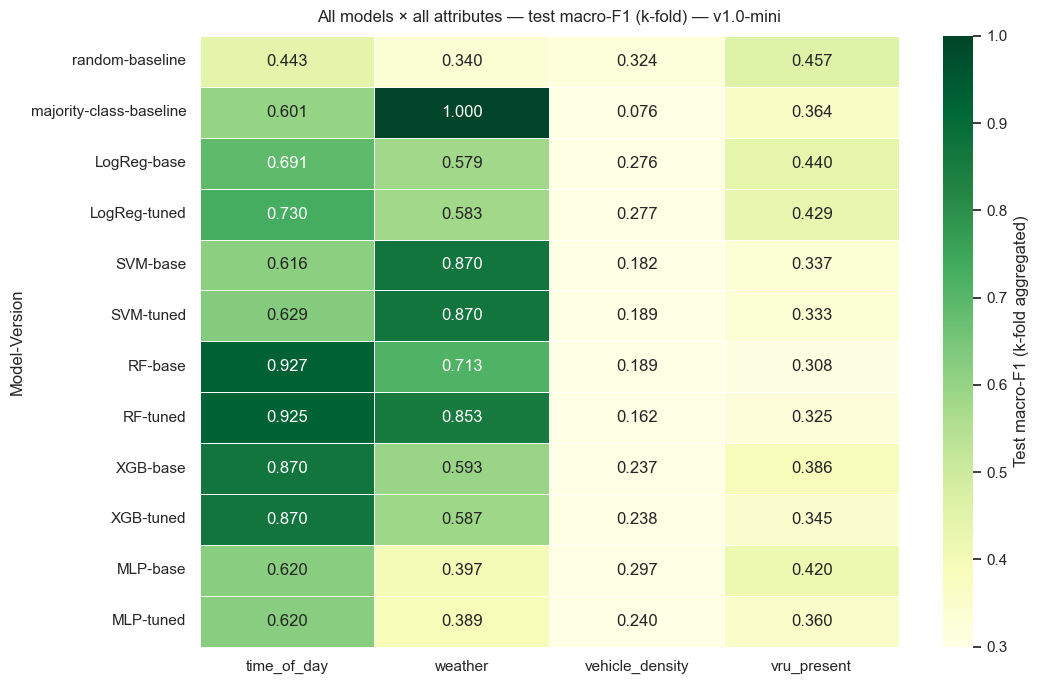

In [10]:
# Visualise as heatmap (numeric rows only)
numeric_df = df_matrix.copy()
for attr in ATTRIBUTES:
    numeric_df[attr] = pd.to_numeric(numeric_df[attr], errors='coerce')

heat_data = numeric_df.set_index(['Model', 'Version'])[ATTRIBUTES]
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='YlGn', vmin=0.3, vmax=1.0,
            ax=ax, cbar_kws={'label': 'Test macro-F1 (k-fold aggregated)'},
            linewidths=0.5)
ax.set_title(f'All models × all attributes — test macro-F1 (k-fold) — {DATASET_VERSION}',
              fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'all_results_matrix_heatmap.png', bbox_inches='tight')
plt.show()

## 4. Cross-Attribute Model Ranking

Which tuned model has the strongest average macro-F1 across all four attributes?

In [11]:
ranking = (tuned_only.groupby('model')['macro_f1']
                       .agg(['mean', 'std', 'min', 'max']).round(3))
ranking = ranking.reindex(MODEL_NAMES)
ranking['mean_rank'] = ranking['mean'].rank(ascending=False).astype(int)
ranking = ranking.sort_values('mean_rank')
ranking.index = [DISPLAY_NAMES[m] for m in ranking.index]
ranking.index.name = 'Model'

print('CROSS-ATTRIBUTE RANKING (tuned, averaged across attributes × folds × seeds):')
display(ranking)
ranking.to_csv(FINAL_DIR / 'cross_attribute_ranking.csv')
print(f'\nSaved → {FINAL_DIR / "cross_attribute_ranking.csv"}')

CROSS-ATTRIBUTE RANKING (tuned, averaged across attributes × folds × seeds):


,mean,std,min,max,mean_rank
Model,,,,,
RF,0.551,0.364,0.090,1.0,1
XGB,0.506,0.295,0.215,1.0,2
LogReg,0.500,0.249,0.171,1.0,3
SVM,0.486,0.300,0.093,1.0,4
MLP,0.403,0.219,0.093,1.0,5



Saved → results\v1.0-mini\final\cross_attribute_ranking.csv


## 5. Top-3 Ranking Per Attribute

In [12]:
top3_rows = []
for attr in ATTRIBUTES:
    sub = tuned_only[tuned_only['attribute'] == attr]
    if sub.empty: continue
    by_model = sub.groupby('model')['macro_f1'].mean().round(3).sort_values(ascending=False)
    for rank, (model_name, score) in enumerate(by_model.head(3).items(), 1):
        top3_rows.append({
            'attribute': attr,
            'rank': ['First', 'Second', 'Third'][rank - 1],
            'model': DISPLAY_NAMES[model_name],
            'macro_f1': score,
        })

df_top3 = pd.DataFrame(top3_rows)
df_top3.to_csv(FINAL_DIR / 'top3_per_attribute.csv', index=False)

# Clean display format
display_rows = []
for attr in ATTRIBUTES:
    sub = df_top3[df_top3['attribute'] == attr].sort_values('rank',
        key=lambda x: x.map({'First': 1, 'Second': 2, 'Third': 3}))
    row = {'attribute': attr}
    for r in ['First', 'Second', 'Third']:
        rsub = sub[sub['rank'] == r]
        if not rsub.empty:
            m = rsub.iloc[0]['model']
            f = rsub.iloc[0]['macro_f1']
            row[r] = f'{m} ({f:.3f})'
    display_rows.append(row)
df_top3_clean = pd.DataFrame(display_rows)
print('TOP-3 (clean format):')
display(df_top3_clean)
print(f'\nSaved → {FINAL_DIR / "top3_per_attribute.csv"}')

TOP-3 (clean format):


,attribute,First,Second,Third
0,time_of_day,RF (0.925),XGB (0.870),LogReg (0.730)
1,weather,SVM (0.870),RF (0.853),XGB (0.587)
2,vehicle_density,LogReg (0.277),MLP (0.240),XGB (0.238)
3,vru_present,LogReg (0.429),MLP (0.360),XGB (0.345)



Saved → results\v1.0-mini\final\top3_per_attribute.csv


## 6. Recall + Precision for Best Models (Per Class)

In [13]:
from sklearn.metrics import precision_score, recall_score

df_preds = pd.read_csv(PRED_DIR / 'predictions_test.csv')

rp_rows = []
for attr in ATTRIBUTES:
    sub = tuned_only[tuned_only['attribute'] == attr]
    if sub.empty: continue
    best_model = sub.groupby('model')['macro_f1'].mean().idxmax()

    # Aggregate predictions across all folds × seeds for this best model
    pred_sub = df_preds[(df_preds['attribute'] == attr) &
                        (df_preds['model'] == best_model) &
                        (df_preds['version'] == 'tuned')]

    # Compute per-fold per-seed precision/recall and average
    per_run = []
    for (fold, seed), grp in pred_sub.groupby(['fold', 'seed']):
        yt = grp['true_label'].values
        yp = grp['pred_label'].values
        num_class = len(CLASS_ORDERS[attr])
        labels = list(range(num_class))
        prec = precision_score(yt, yp, average=None, labels=labels, zero_division=0)
        rec  = recall_score(yt, yp, average=None, labels=labels, zero_division=0)
        per_run.append({'precision': prec, 'recall': rec})

    mean_prec = np.mean([r['precision'] for r in per_run], axis=0)
    mean_rec  = np.mean([r['recall']    for r in per_run], axis=0)

    for cls_i, cls_name in enumerate(CLASS_ORDERS[attr]):
        rp_rows.append({
            'attribute':   attr,
            'best_model':  DISPLAY_NAMES[best_model],
            'class':       cls_name,
            'precision':   round(float(mean_prec[cls_i]), 3),
            'recall':      round(float(mean_rec[cls_i]),  3),
        })

df_rp = pd.DataFrame(rp_rows)
print('RECALL + PRECISION FOR BEST MODELS (per class, mean across folds × seeds):')
display(df_rp)
df_rp.to_csv(FINAL_DIR / 'recall_precision_best.csv', index=False)
print(f'\nSaved → {FINAL_DIR / "recall_precision_best.csv"}')

RECALL + PRECISION FOR BEST MODELS (per class, mean across folds × seeds):


,attribute,best_model,class,precision,recall
0,time_of_day,RF,day,0.941,0.999
1,time_of_day,RF,night,0.600,0.518
2,weather,SVM,clear,1.000,0.982
3,weather,SVM,rain,0.000,0.000
4,vehicle_density,LogReg,low,0.251,0.208
5,vehicle_density,LogReg,medium,0.495,0.533
6,vehicle_density,LogReg,high,0.513,0.477
7,vru_present,LogReg,absent,0.361,0.252
8,vru_present,LogReg,present,0.582,0.677



Saved → results\v1.0-mini\final\recall_precision_best.csv


## 7. Fold-by-Fold Breakdown (transparency)

For each attribute, show macro-F1 per fold for the winning tuned model.

In [14]:
fold_break_rows = []
for attr in ATTRIBUTES:
    sub = tuned_only[tuned_only['attribute'] == attr]
    if sub.empty: continue
    best_model = sub.groupby('model')['macro_f1'].mean().idxmax()
    msub = sub[sub['model'] == best_model]
    per_fold = msub.groupby('fold')['macro_f1'].agg(['mean', 'std']).round(3)
    for fold_id, row_data in per_fold.iterrows():
        fold_break_rows.append({
            'attribute': attr,
            'best_model': DISPLAY_NAMES[best_model],
            'fold': fold_id,
            'macro_f1_mean': row_data['mean'],
            'macro_f1_std': row_data['std'],
        })

df_fold_break = pd.DataFrame(fold_break_rows)
print('Per-fold breakdown for winning tuned model per attribute:')
display(df_fold_break.pivot(index='attribute', columns='fold', values='macro_f1_mean'))
df_fold_break.to_csv(FINAL_DIR / 'fold_breakdown.csv', index=False)
print(f'\nSaved → {FINAL_DIR / "fold_breakdown.csv"}')

Per-fold breakdown for winning tuned model per attribute:


fold,0,1,2,3,4
attribute,,,,,
time_of_day,0.803,0.996,0.992,1.000,0.832
vehicle_density,0.303,0.199,0.468,0.236,0.180
vru_present,0.334,0.368,0.484,0.578,0.379
weather,NaN,0.481,1.000,1.000,1.000



Saved → results\v1.0-mini\final\fold_breakdown.csv


## 8. Headline Summary JSON

In [15]:
summary = {
    'dataset_version': DATASET_VERSION,
    'methodology': '5-fold scene-aware cross-validation (Demšar 2006)',
    'attributes': ATTRIBUTES,
    'n_skipped_combos': len(skipped_combos),
    'skipped_combos': skipped_combos,
    'best_model_per_attribute': {
        row['attribute']: row['best_model'] for _, row in df_headline.iterrows()
    },
    'best_macro_f1_per_attribute': {
        row['attribute']: row['macro_f1'] for _, row in df_headline.iterrows()
    },
    'best_overall_average_model': ranking.index[0],
    'best_overall_average_macro_f1': float(ranking.iloc[0]['mean']),
}

with open(FINAL_DIR / 'headline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Saved → {FINAL_DIR / "headline_summary.json"}')
print(json.dumps(summary, indent=2))

Saved → results\v1.0-mini\final\headline_summary.json
{
  "dataset_version": "v1.0-mini",
  "methodology": "5-fold scene-aware cross-validation (Dem\u0161ar 2006)",
  "attributes": [
    "time_of_day",
    "weather",
    "vehicle_density",
    "vru_present"
  ],
  "n_skipped_combos": 1,
  "skipped_combos": [
    {
      "fold": 0,
      "attribute": "weather",
      "reason": "train_single_class",
      "n_train_classes": 1,
      "n_test_classes": 2
    }
  ],
  "best_model_per_attribute": {
    "time_of_day": "RF",
    "weather": "SVM",
    "vehicle_density": "LogReg",
    "vru_present": "LogReg"
  },
  "best_macro_f1_per_attribute": {
    "time_of_day": "0.925 \u00b1 0.143",
    "weather": "0.870 \u00b1 0.235",
    "vehicle_density": "0.277 \u00b1 0.108",
    "vru_present": "0.429 \u00b1 0.098"
  },
  "best_overall_average_model": "RF",
  "best_overall_average_macro_f1": 0.551
}


---
## Findings & Decisions

### Headline numbers: best tuned model per attribute

| Attribute | Best tuned model | Mean macro-F1 | Mean accuracy | Folds evaluated |
|---|---|---:|---:|---:|
| `time_of_day` | Random Forest | 0.925 ± 0.143 | 0.959 ± 0.077 | 5 |
| `weather` | SVM | 0.870 ± 0.235 | 0.982 ± 0.033 | 4 |
| `vehicle_density` | Logistic Regression | 0.277 ± 0.109 | 0.298 ± 0.132 | 5 |
| `vru_present` | Logistic Regression | 0.427 ± 0.095 | 0.560 ± 0.217 | 5 |

### Main result pattern

The strongest results are obtained for `time_of_day` and `weather`, while `vehicle_density` and `vru_present` are substantially harder. This supports the interpretation that hand-crafted global image features are more effective for photometric scene attributes than for object-counting or localised object-presence tasks.

### Weather-result caution

The `weather` result must be interpreted carefully. The best tuned model achieved high macro-F1 across the evaluated folds, but fold 0 was skipped because the training set contained only one weather class. In addition, the per-class analysis shows zero precision and zero recall for the `rain` class. Therefore, the weather result mainly reflects performance on the dominant `clear` class and should not be presented as strong evidence of robust rain detection.

### Model comparison

Across the tuned models, Random Forest has the highest average macro-F1 across attributes, followed by XGBoost, Logistic Regression, SVM, and MLP. However, this should be interpreted as an overall average ranking rather than a universal best model, because performance varies strongly by target attribute.

### Attribute-specific observations

- `time_of_day`: Random Forest performs best and achieves high day-class performance, but night recall remains weaker than day recall.
- `weather`: SVM performs best among tuned models, but rain detection is not validated reliably on v1.0-mini.
- `vehicle_density`: Logistic Regression performs best, but macro-F1 remains low, showing that density estimation is difficult using these hand-crafted image features.
- `vru_present`: Logistic Regression performs best, but recall and precision are moderate, suggesting that VRU presence is not reliably captured by global image descriptors alone.

### v1.0-mini limitations

- One fold-attribute combination was skipped: `fold 0 / weather`.
- The rain class is concentrated in a single scene, limiting weather generalisation.
- Some fold-level scores are artificially high when the test fold contains only the dominant class.
- Results should therefore be treated as pipeline-validation evidence on v1.0-mini, not as final full-dataset generalisation.

### Next analyses

- Notebook 08b should inspect confusion matrices, ROC curves, and statistical comparisons.
- Notebook 08c should analyse feature importance, error cases, and the roadmap for scaling to the full dataset.